In [18]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

In [19]:
# === Load and display best hyperparameters from all grid searches ===
import os
import joblib
import pandas as pd

# === specify model directories ===
grid_search_paths = {
    "Lasso Stability Selection": "../models/lasso_stability_selection_grid_search/lasso_gridsearch.joblib",
    "Lasso SelectKBest": "../models/lasso_selectkbest_grid_search/lasso_gridsearch.joblib",
    "Lasso Bootstrapped SelectKBest": "../models/lasso_bootstrapped_selectkbest_grid_search/lasso_gridsearch.joblib",
    "Lasso No Feature Selection": "../models/lasso_no_feature_selection_grid_search/lasso_gridsearch.joblib",
    # "RandomForest SelectKBest": "../models/randomforest_selectkbest_grid_search/rf_gridsearch.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/gridsearch.joblib",
    "XGBoost No Feature Selection": "../models/xgboost_grid_search/gridsearch.joblib",
    "SVM SelectKBest": "../models/svm_selectkbest_grid_search/gridsearch.joblib"
}

# === Load and collect best parameters ===
results = []

for model_name, grid_path in grid_search_paths.items():
    if not os.path.exists(grid_path):
        print(f"Skipping missing grid search: {grid_path}")
        continue

    print(f"\nBest Hyperparameters for {model_name}:")
    grid_search = joblib.load(grid_path)
    best_params = grid_search.best_params_
    print(best_params)



Best Hyperparameters for Lasso Stability Selection:
{'clf__C': 10, 'select__fpr_alpha': 0.01, 'select__n_boots': 50, 'select__stability_threshold': 0.9}

Best Hyperparameters for Lasso SelectKBest:
{'clf__C': 1, 'select__k': 50}

Best Hyperparameters for Lasso Bootstrapped SelectKBest:
{'clf__C': 1, 'select__k': 50, 'select__n_bootstrap': 50, 'select__threshold': 0.6}

Best Hyperparameters for Lasso No Feature Selection:
{'clf__C': 10}

Best Hyperparameters for XGBoost SelectKBest:
{'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 0.8, 'select__k': 50}

Best Hyperparameters for XGBoost No Feature Selection:
{'clf__colsample_bytree': 1.0, 'clf__gamma': 0.1, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.7}

Best Hyperparameters for SVM SelectKBest:
{'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'select__k': 50}


In [20]:
# === specify the exact model paths to be evaluated ===
model_paths = {
    "Lasso Stability Selection": "../models/lasso_stability_selection_grid_search/lasso_model.joblib",
    "Lasso SelectKBest": "../models/lasso_selectkbest_grid_search/lasso_model.joblib",
    "Lasso Bootstrapped SelectKBest": "../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib",
    "Lasso no feature selection": "../models/lasso_no_feature_selection_grid_search/lasso_model.joblib",
    # "RandomForest SelectKBest": "../models/randomforest_selectkbest_grid_search/rf_model.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/model.joblib",
    "XGBoost no feature selection": "../models/xgboost_grid_search/model.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/model.joblib",
    "SVM SelectKBest": "../models/svm_selectkbest_grid_search/model.joblib"
}

# === Directories for data and preprocessing ===
DATA_DIR = "../split_data"

# === Load data ===
print("Loading split data...")
X_val = joblib.load(os.path.join(DATA_DIR, "X_test.joblib")) #FIXME
y_val = joblib.load(os.path.join(DATA_DIR, "y_test.joblib")) #FIXME

# === Evaluate models ===
results = []

for model_name, model_path in model_paths.items():
    if not os.path.exists(model_path):
        print(f"Skipping missing model: {model_path}")
        continue

    print(f"\nEvaluating {model_path}...")
    model = joblib.load(model_path)

    # Get predictions
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    # Compute metrics
    auc = roc_auc_score(y_val, y_prob)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    results.append({
        "Model": model_name,
        "Path": model_path,
        "AUROC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    })

# === Display results ===
results_df = pd.DataFrame(results).sort_values(by="AUROC", ascending=False)

print("\nModel Performance Comparison:\n")
print(results_df.to_string(index=False, float_format="%.4f"))

# # Save results
# # results_df.to_csv("model_comparison_selected.csv", index=False)
# # print("\nResults saved to model_comparison_selected.csv")


Loading split data...

Evaluating ../models/lasso_stability_selection_grid_search/lasso_model.joblib...

Evaluating ../models/lasso_selectkbest_grid_search/lasso_model.joblib...

Evaluating ../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib...

Evaluating ../models/lasso_no_feature_selection_grid_search/lasso_model.joblib...

Evaluating ../models/xgboost_selectkbest_grid_search/model.joblib...

Evaluating ../models/xgboost_grid_search/model.joblib...


/oscar/home/gchermsi/newenv-py/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Evaluating ../models/svm_selectkbest_grid_search/model.joblib...

Model Performance Comparison:

                         Model                                                                    Path  AUROC  Precision  Recall     F1  TP  FP  TN  FN
    Lasso no feature selection     ../models/lasso_no_feature_selection_grid_search/lasso_model.joblib 0.7336     0.3478  0.6667 0.4571   8  15  41   4
           XGBoost SelectKBest                  ../models/xgboost_selectkbest_grid_search/model.joblib 0.7009     0.0000  0.0000 0.0000   0   2  54  12
             Lasso SelectKBest              ../models/lasso_selectkbest_grid_search/lasso_model.joblib 0.6890     0.3333  0.5000 0.4000   6  12  44   6
  XGBoost no feature selection                              ../models/xgboost_grid_search/model.joblib 0.6771     0.0000  0.0000 0.0000   0   0  56  12
Lasso Bootstrapped SelectKBest ../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib 0.6652     0.3571  0.4167 0.3846   5   

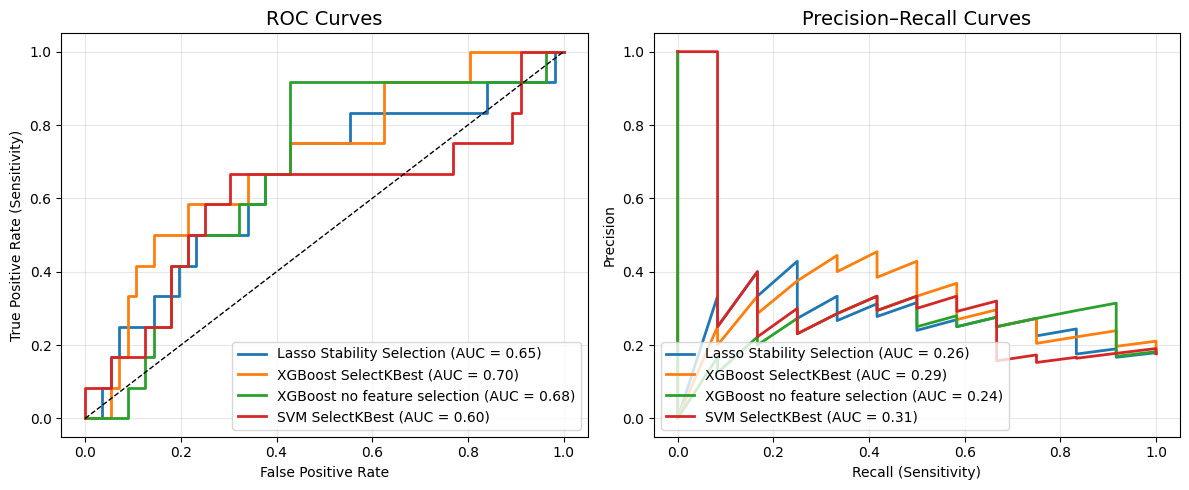

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import joblib

# Subset of models for graphing
lasso_model_paths = {
    "Lasso Stability Selection": "../models/lasso_stability_selection_grid_search/lasso_model.joblib",
    "Lasso SelectKBest": "../models/lasso_selectkbest_grid_search/lasso_model.joblib",
    "Lasso Bootstrapped SelectKBest": "../models/lasso_bootstrapped_selectkbest_grid_search/lasso_model.joblib",
    "Lasso no feature selection": "../models/lasso_no_feature_selection_grid_search/lasso_model.joblib"
}

best_model_paths = {
    "Lasso Stability Selection": "../models/lasso_stability_selection_grid_search/lasso_model.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/model.joblib",
    "XGBoost no feature selection": "../models/xgboost_grid_search/model.joblib",
    "XGBoost SelectKBest": "../models/xgboost_selectkbest_grid_search/model.joblib",
    "SVM SelectKBest": "../models/svm_selectkbest_grid_search/model.joblib"
}


# Initialize plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC and PR plots
for label, path in best_model_paths.items():
    model = joblib.load(path)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.2f})")

    # Precision–Recall
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, lw=2, label=f"{label} (AUC = {pr_auc:.2f})")

# ROC formatting
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves", fontsize=14)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR formatting
axes[1].set_title("Precision–Recall Curves", fontsize=14)
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
nonzero_counts = {}

for name, path in model_paths.items():
    model = joblib.load(path)
    clf = model.named_steps["clf"]  # your logistic regression or similar
    coefs = clf.coef_.ravel()
    print(len(coefs))
    nonzero_counts[name] = np.sum(coefs != 0)

for name, count in nonzero_counts.items():
    print(f"{name}: {count} non-zero coefficients")


45
50
50
35031


AttributeError: Coefficients are not defined for Booster type None

In [24]:
import numpy as np
import pandas as pd
import joblib

def get_feature_info(model):
    """Return nonzero features, their names, and weights for a sklearn pipeline."""
    # Core components
    steps = model.named_steps
    pre = steps.get("preprocessor")
    clf = steps["clf"]

    # Step 1: Get initial feature names
    feature_names = np.array(pre.get_feature_names_out())

    # Step 2: Apply variance threshold if it exists
    if "var_thresh" in steps and hasattr(steps["var_thresh"], "get_support"):
        var_mask = steps["var_thresh"].get_support()
        feature_names = feature_names[var_mask]

    # Step 3: Apply feature selector if it exists
    if "select" in steps:
        select = steps["select"]
        if hasattr(select, "get_support"):
            select_mask = select.get_support()
            feature_names = feature_names[select_mask]
        else:
            # Fallback for selectors without get_support (e.g., StabilitySelection)
            feature_names = feature_names[:clf.coef_.shape[1]]

    # Step 4: Extract coefficients
    coefs = clf.coef_.ravel()

    # Step 5: Filter nonzero coefficients
    nonzero_mask = coefs != 0
    nonzero_features = feature_names[nonzero_mask]
    nonzero_coefs = coefs[nonzero_mask]

    # Step 6: Create dataframe
    df = pd.DataFrame({
        "feature": nonzero_features,
        "weight": nonzero_coefs
    }).sort_values("weight", key=abs, ascending=False)

    return df, len(nonzero_features)

feature_dfs = {}

for name, path in lasso_model_paths.items():
    model = joblib.load(path)
    df, count = get_feature_info(model)
    feature_dfs[name] = df
    print(f"{name}: {count} nonzero features")
    print(df.head(10))
    print()

Lasso Stability Selection: 45 nonzero features
                   feature    weight
43      mutation__SOX9_mut -5.312203
36   mutation__ERBB2IP_mut -3.996317
40       mutation__RLF_mut -3.679554
42  mutation__SMARCAD1_mut -3.315776
37     mutation__IGF2R_mut -2.988948
41    mutation__RNF213_mut -2.712752
39      mutation__MUC4_mut -1.843063
38     mutation__MED23_mut -1.262407
44     mutation__WDR87_mut -1.248082
3               mrna__ASB9  1.057681

Lasso SelectKBest: 42 nonzero features
               feature    weight
40  mutation__MUC4_mut -1.786710
27         mrna__SMYD4 -1.063544
6       mrna__C9orf103 -0.789195
2           mrna__ASB2 -0.733530
39        mrna__ZNF853 -0.693163
31          mrna__TCP1  0.654428
1        mrna__ARFGAP3 -0.642095
3           mrna__ASB9  0.631713
14          mrna__EPT1 -0.630076
28          mrna__ST18  0.592083

Lasso Bootstrapped SelectKBest: 45 nonzero features
           feature    weight
33     mrna__SMYD4 -0.960909
4   mrna__C9orf103  0.739577
13 

In [ ]:
# Get sets of features
sets = {name: set(df["feature"]) for name, df in feature_dfs.items()}

# Pairwise intersections
for name1, s1 in sets.items():
    for name2, s2 in sets.items():
        if name1 < name2:
            overlap = len(s1 & s2)
            print(f"{name1} & {name2}: {overlap} shared features")

# Get sets of features
sets = {name: set(df["feature"]) for name, df in feature_dfs.items()}

# Pairwise intersections (with feature names)
for name1, s1 in sets.items():
    for name2, s2 in sets.items():
        if name1 < name2:  # to avoid duplicates
            overlap = s1 & s2
            print(f"\n{name1} & {name2}: {len(overlap)} shared features")
            if overlap:
                print(", ".join(sorted(overlap)))
            else:
                print("(No shared features)")



In [ ]:
# Find shared across all models
shared_all = set.intersection(*(set(df["feature"]) for df in feature_dfs.values()))
print(f"Shared across ALL models: {len(shared_all)}")
print(shared_all)

# pairwise overlaps
model_names = list(feature_dfs.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        overlap = set(feature_dfs[m1]["feature"]) & set(feature_dfs[m2]["feature"])
        print(f"Shared between {m1} and {m2}: {len(overlap)}")

